In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os


## creating simple classifier using mnist dataset

In [13]:
mnist=tf.keras.datasets.mnist

In [14]:
mnist

<module 'keras.datasets.mnist' from 'e:\\Deep Learning\\venv\\lib\\site-packages\\keras\\datasets\\mnist\\__init__.py'>

In [15]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [16]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [17]:
X_test.shape

(10000, 28, 28)

In [18]:
X_valid,X_train=X_train[:5000]/255.,X_train[5000:]/255.
y_valid,y_train=y_train[:5000],y_train[5000:]

X_test=X_test/255.

In [19]:
#Train-55000
#Test=10000
#val-5000


In [20]:
X_train.shape,X_test.shape,y_train.shape,X_valid.shape

((55000, 28, 28), (10000, 28, 28), (55000,), (5000, 28, 28))

In [21]:
len(X_train[5000:])

50000

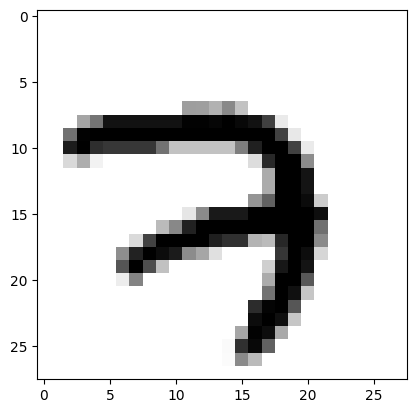

In [22]:
plt.imshow(X_train[0],cmap='binary')
plt.show()

<Axes: >

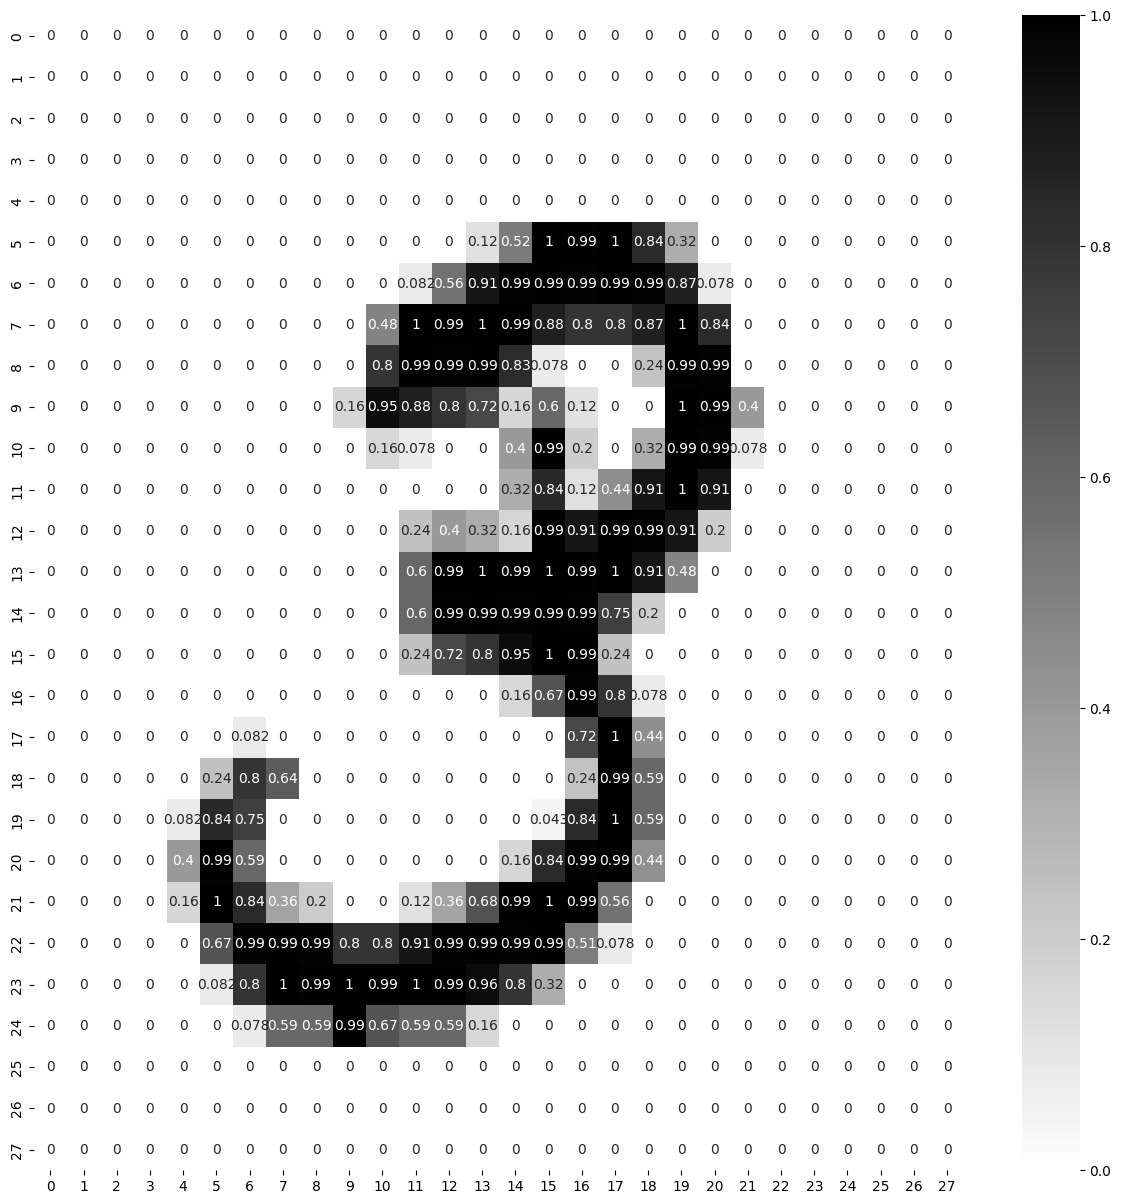

In [23]:
plt.figure(figsize=(15,15))
sns.heatmap(X_train[1],annot=True,cmap='binary')

In [24]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout

In [25]:
##CReating layers of ANN

Layers=[tf.keras.layers.Flatten(input_shape=[28,28],name='inputLayer'),
        tf.keras.layers.Dense(300,activation='relu',name='hiddenLayer1',kernel_regularizer=regularizers.L2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(100,activation='relu',name='hiddenLayer2'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10,activation='softmax',name='outputLayer')]

model_clf=tf.keras.models.Sequential(Layers)

e:\Deep Learning\venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
model_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hiddenLayer1 (Dense)            │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hiddenLayer2 (Dense)            │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,810 (1.02 MB)

 Trainable params: 267,210 (1.02 MB)

 Non-trainable params: 600 (2.34 KB)

## Method 2

In [27]:
from keras.models import Sequential
from keras.layers import Dense,Flatten

model=Sequential()
model.add(Flatten(input_shape=[28,28],name='inputLayer'))
model.add(Dense(units=64,activation='relu',kernel_regularizer=regularizers.L2(1e-4)))
model.add(Dropout(0.2))
model.add(Dense(units=32,activation='relu',kernel_regularizer=regularizers.L1L2(l1=1e-5,l2=1e-4)))
model.add(Dropout(0.1))
model.add(Dense(units=64,activation='relu',kernel_regularizer=regularizers.L1(1e-5)))
model.add(Dropout(0.2))
model.add(Dense(units=10,activation='softmax'))

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,082 (215.16 KB)

 Trainable params: 55,082 (215.16 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
loss_fn='sparse_categorical_crossentropy'
optimizer='SGD'
metrics=['accuracy']

model.compile(loss=loss_fn,
              optimizer=optimizer,
              metrics=metrics
                )

In [30]:
epochs=5
validation_set=(X_valid,y_valid)

history=model.fit(X_train,y_train,epochs=epochs,validation_data=validation_set,batch_size=32)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6193 - loss: 1.1828 - val_accuracy: 0.8824 - val_loss: 0.4538
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8344 - loss: 0.5681 - val_accuracy: 0.9142 - val_loss: 0.3214
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8726 - loss: 0.4505 - val_accuracy: 0.9330 - val_loss: 0.2643
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8939 - loss: 0.3808 - val_accuracy: 0.9404 - val_loss: 0.2309
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9051 - loss: 0.3441 - val_accuracy: 0.9480 - val_loss: 0.2113


In [31]:
df=pd.DataFrame(history.history)
df

,accuracy,loss,val_accuracy,val_loss
0,0.619291,1.182848,0.8824,0.453785
1,0.834436,0.568086,0.9142,0.321432
2,0.872582,0.450523,0.9330,0.264293
3,0.893855,0.380810,0.9404,0.230909
4,0.905055,0.344135,0.9480,0.211317


<Axes: >

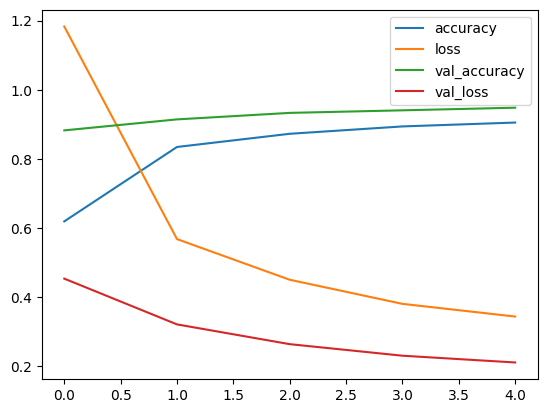

In [32]:
df.plot()

In [33]:
from keras.models import Sequential
from keras.layers import Dense,Flatten

model2=Sequential()
model2.add(Flatten(input_shape=[28,28],name='inputLayer'))
model2.add(Dense(units=64,activation='relu',kernel_initializer=tf.keras.initializers.HeNormal(seed=None) )) # type: ignore
model2.add(Dropout(0.2))
model2.add(Dense(units=32,activation='relu',kernel_regularizer=regularizers.L1L2(l1=1e-5,l2=1e-4) ,kernel_initializer=tf.keras.initializers.HeNormal(seed=None)))
model2.add(Dropout(0.1))
model2.add(Dense(units=64,activation='relu',kernel_regularizer=regularizers.L1(1e-5),kernel_initializer=tf.keras.initializers.HeNormal(seed=None)))
model2.add(Dropout(0.2))
model2.add(Dense(units=10,activation='softmax'))

e:\Deep Learning\venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,082 (215.16 KB)

 Trainable params: 55,082 (215.16 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
loss_fn='sparse_categorical_crossentropy'
optimizer='SGD'
sgd=tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9)
metrics=['accuracy']

model2.compile(loss=loss_fn,
              optimizer=sgd,
              metrics=metrics
                )

In [36]:
epochs=5
validation_set=(X_valid,y_valid)

history=model2.fit(X_train,y_train,epochs=epochs,validation_data=validation_set,batch_size=32)

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8320 - loss: 0.5497 - val_accuracy: 0.9436 - val_loss: 0.2030
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9163 - loss: 0.3026 - val_accuracy: 0.9546 - val_loss: 0.1663
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9303 - loss: 0.2519 - val_accuracy: 0.9636 - val_loss: 0.1407
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9405 - loss: 0.2226 - val_accuracy: 0.9640 - val_loss: 0.1383
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9453 - loss: 0.2069 - val_accuracy: 0.9642 - val_loss: 0.1364


In [37]:
df2=pd.DataFrame(history.history)
df2

,accuracy,loss,val_accuracy,val_loss
0,0.831964,0.549687,0.9436,0.202995
1,0.916345,0.302603,0.9546,0.166262
2,0.930327,0.251890,0.9636,0.140676
3,0.940527,0.222630,0.9640,0.138287
4,0.945327,0.206860,0.9642,0.136418


<Axes: >

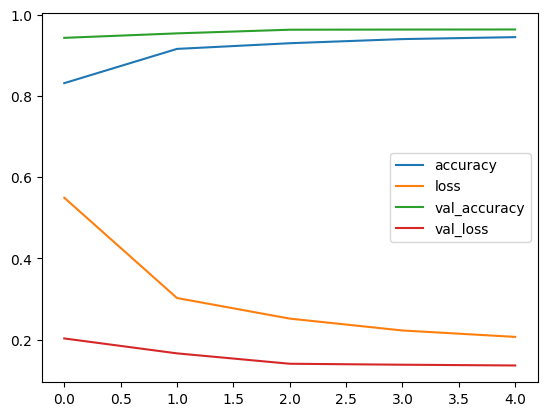

In [38]:
df2.plot()

In [40]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9456 - loss: 0.2127


[0.21266362071037292, 0.9455999732017517]

In [42]:
y_prob=model.predict(X_test)
y_prob.round(3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0.   , 0.   , 0.   , ..., 0.998, 0.   , 0.001],
       [0.   , 0.   , 0.991, ..., 0.   , 0.001, 0.   ],
       [0.   , 0.994, 0.001, ..., 0.002, 0.001, 0.   ],
       ...,
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.013],
       [0.004, 0.002, 0.001, ..., 0.   , 0.134, 0.002],
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ]],
      shape=(10000, 10), dtype=float32)

In [43]:
y_prob

array([[3.63689423e-06, 1.02427939e-05, 1.01378864e-05, ...,
        9.98274565e-01, 4.55536610e-06, 1.40250952e-03],
       [8.90984011e-05, 3.47904599e-04, 9.90515351e-01, ...,
        5.27148950e-05, 8.42640293e-04, 5.09367874e-06],
       [3.05898546e-04, 9.94406581e-01, 6.61731581e-04, ...,
        2.16411194e-03, 6.20772247e-04, 1.84857054e-04],
       ...,
       [3.38959376e-06, 4.45468686e-06, 4.59906078e-05, ...,
        1.15527015e-04, 1.68407554e-04, 1.30337160e-02],
       [3.85019975e-03, 2.24429881e-03, 1.35559076e-03, ...,
        7.59010218e-05, 1.33754313e-01, 2.10337713e-03],
       [5.76928942e-05, 6.69509319e-08, 1.26153900e-04, ...,
        2.93081581e-09, 3.36410403e-06, 2.54726160e-06]],
      shape=(10000, 10), dtype=float32)

In [45]:
y_pred=np.argmax(y_prob,axis=-1)
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))